In [1]:
# http://compbio.cs.toronto.edu/SNF/SNF/Software.html

In [2]:
# install.packages("heatmap.plus")
# devtools::install_github("maxconway/SNFtool")

In [3]:
# SNF itself is UNSUPERVISED.

# SNF (Similarity Network Fusion) does not use labels.
# It does not learn from outcomes or classes.
# It only fuses sample–sample similarity networks built from multiple data modalities.

In [4]:
cat("Similarity Network Fusion (SNF) is a new computational method for data integration.  
    
Briefly, SNF combines many different types of measurements (such as mRNA expression data, DNA methylation, miRNA expression 
    
and more - clinical data, questionnaires, image data, etc) for a given set of samples (e.g. patients). 
    
SNF first constructs a sample similarity network for each of the data types and then iteratively integrates these networks 
    
using a novel network fusion method. 
    
Working in the sample network space allows SNF to avoid dealing with different scale, 

collection bias and noise in different data types. 
    
Integrating data in a non-linear fashion allows SNF to take advantage of the common as well as complementary information 
    
in different data types.")

Similarity Network Fusion (SNF) is a new computational method for data integration.  
    
Briefly, SNF combines many different types of measurements (such as mRNA expression data, DNA methylation, miRNA expression 
    
and more - clinical data, questionnaires, image data, etc) for a given set of samples (e.g. patients). 
    
SNF first constructs a sample similarity network for each of the data types and then iteratively integrates these networks 
    
using a novel network fusion method. 
    
Working in the sample network space allows SNF to avoid dealing with different scale, 

collection bias and noise in different data types. 
    
Integrating data in a non-linear fashion allows SNF to take advantage of the common as well as complementary information 
    
in different data types.

In [5]:
cat("

An example on the task of fusing two data types: mRNA expression and DNA methylation for the same cohort of patients. 

1. Construct patient similarity matrices for each data type using pairwise correlation   

2. Patient similarity matrices are equivalent to patient similarity networks where patients 
are nodes and edges represent patients’ pairwise similarities. 

3. Starting with the patient similarity networks run the patient network fusion, 
iteratively updating each of the networks with the information from the other networks, making them more similar with each step. 

4. The final fused network of patients to which the SNF process has converged. 
Edge color indicates which data type has contributed to the given similarity. 

")



An example on the task of fusing two data types: mRNA expression and DNA methylation for the same cohort of patients. 

1. Construct patient similarity matrices for each data type using pairwise correlation   

2. Patient similarity matrices are equivalent to patient similarity networks where patients 
are nodes and edges represent patients’ pairwise similarities. 

3. Starting with the patient similarity networks run the patient network fusion, 
iteratively updating each of the networks with the information from the other networks, making them more similar with each step. 

4. The final fused network of patients to which the SNF process has converged. 
Edge color indicates which data type has contributed to the given similarity. 



In [6]:
# Notes :

# The code uses a function affinityMatrix to convert the Distance Matrix into an Affinity Matrix. 
# The standard mathematical method for this in spectral clustering (which SNF is based on) is the Gaussian Kernel 
# (also known as the Radial Basis Function or Heat Kernel)

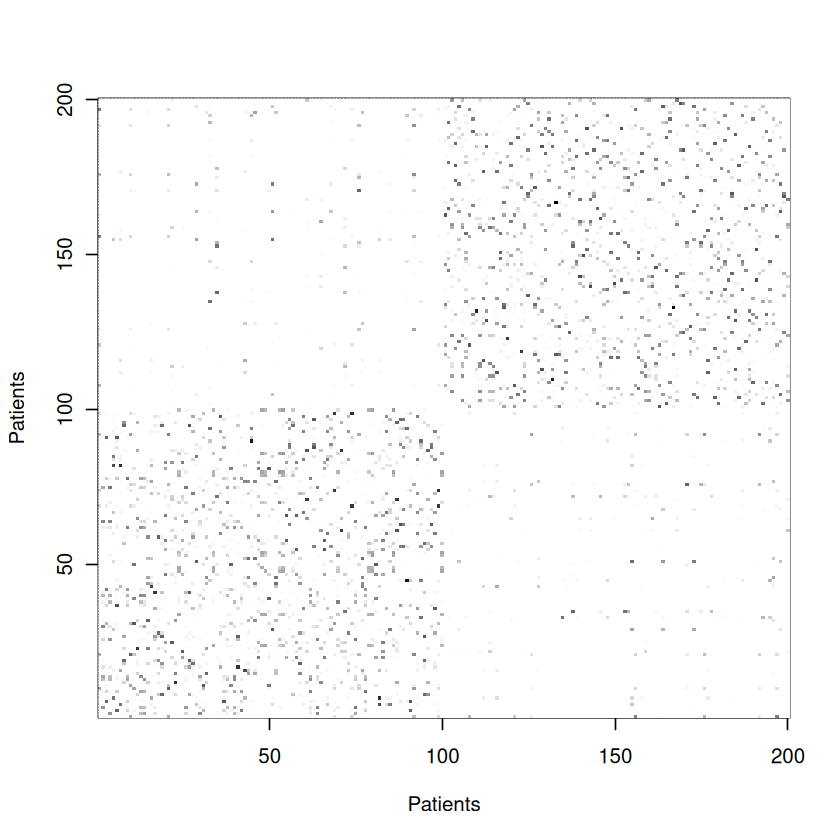

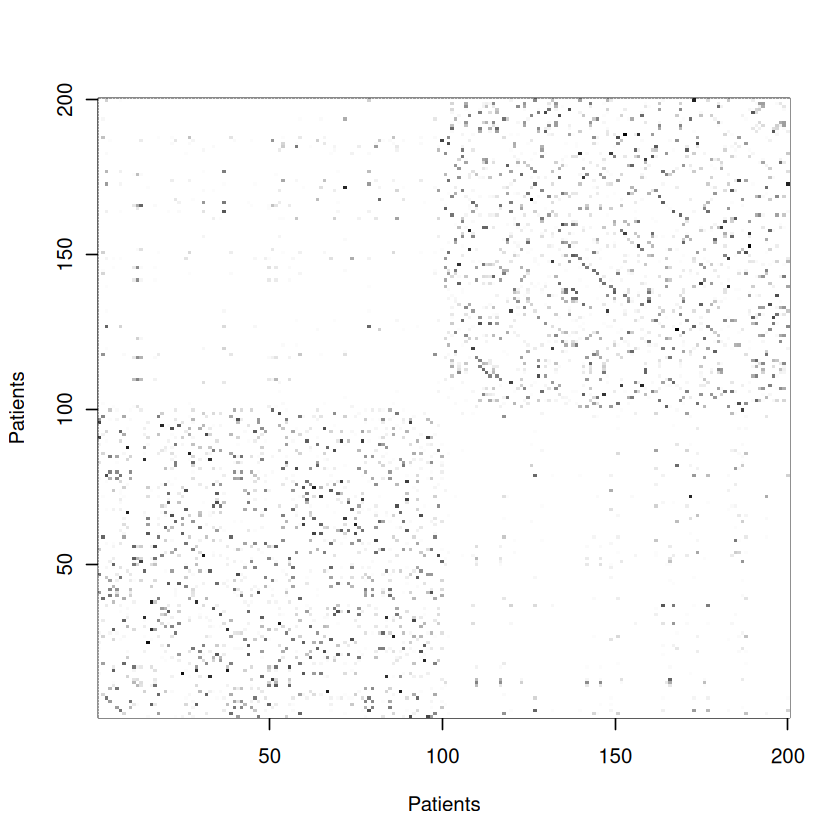


NMI(group, truelabel) = 0.959566

Concordance Network NMI matrix:
          [,1]       [,2]       [,3]
[1,] 1.0000000 0.33687988 0.12774673
[2,] 0.3368799 1.00000000 0.02450331
[3,] 0.1277467 0.02450331 1.00000000

--- Running Multi-view Example ---

Concordance_matrix (fused vs each view):
           [,1]       [,2]
[1,] 1.00000000 0.02450331
[2,] 0.02450331 1.00000000

Multi-view NMI(clustering, label) = 0.959566

--- Running Label Propagation ---

Label propagation accuracy = 1.000000


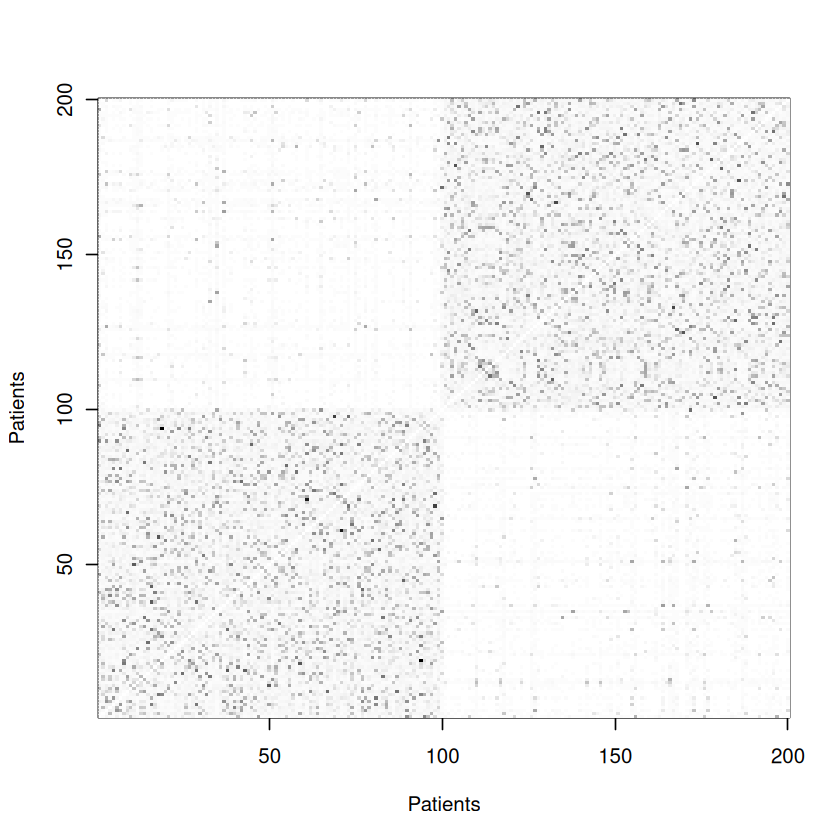

In [7]:
library(SNFtool)

# ----------------------------------------------------------
# 1) Parameters
# ----------------------------------------------------------
K     <- 20   # number of neighbors
alpha <- 0.5  # hyperparameter (maps to 'sigma' in this package)
T     <- 10   # SNF iterations

# ----------------------------------------------------------
# 2) Load built-in example data: Data1, Data2
# ----------------------------------------------------------
data(Data1)
data(Data2)

# Verify data dimensions match
stopifnot(nrow(Data1) == nrow(Data2))
n <- nrow(Data1)

# Create Ground Truth labels (Cluster 1 vs Cluster 2)
truelabel <- c(rep(1, n/2), rep(2, n/2))

# ----------------------------------------------------------
# 3) Distance matrices (SQUARED Euclidean)
# ----------------------------------------------------------
# dist2 calculates squared Euclidean distance
Dist1 <- dist2(as.matrix(Data1), as.matrix(Data1))
Dist2 <- dist2(as.matrix(Data2), as.matrix(Data2))

# ----------------------------------------------------------
# 4) Build similarity graphs (affinity matrices)
# ----------------------------------------------------------
# FIX: Use 'sigma = alpha'. The package expects 'sigma'.
W1 <- affinityMatrix(Dist1, K = K, sigma = alpha)
W2 <- affinityMatrix(Dist2, K = K, sigma = alpha)

# Visualize initial clusters
displayClusters(W1, truelabel)
displayClusters(W2, truelabel)

# ----------------------------------------------------------
# 6) Fuse graphs with SNF
# ----------------------------------------------------------
W <- SNF(list(W1, W2), K = K, t = T)

# ----------------------------------------------------------
# 7) Cluster fused network (spectral clustering)
# ----------------------------------------------------------
C <- 2   # We know there are 2 true clusters
group <- spectralClustering(W, K = C)

displayClusters(W, group)

# ----------------------------------------------------------
# 8) Evaluate clustering quality (NMI vs truth)
# ----------------------------------------------------------
SNFNMI <- calNMI(group, truelabel)
cat(sprintf("\nNMI(group, truelabel) = %f\n", SNFNMI))

# ----------------------------------------------------------
# 9) Concordance between fused network and each individual
# ----------------------------------------------------------
# FIX: Added 'C' as the second argument.
ConcordanceMatrix <- concordanceNetworkNMI(list(W, W1, W2), C)
cat("\nConcordance Network NMI matrix:\n")
print(ConcordanceMatrix)

############################################################
# Multi-view example (Modified for missing Digits data)
############################################################
cat("\n--- Running Multi-view Example ---\n")

# FIX : The 'Digits' dataset is missing.
# We will create 'dataL' using Data1 and Data2 to let the code run.

dataL <- list(as.matrix(Data1), as.matrix(Data2))
label <- truelabel
C_multi <- 2  # We are using Data1/Data2, so C is 2, not 3.

# Parameters
K     <- 20
alpha <- 0.5
T     <- 20

# Calculate squared distances for the list
distL <- lapply(dataL, function(x) dist2(x, x))

# FIX: Use 'sigma = alpha'
affinityL <- lapply(distL, function(d) affinityMatrix(d, K = K, sigma = alpha))

# FIX: Passed C_multi (2) instead of 3
Concordance_matrix <- concordanceNetworkNMI(affinityL, C_multi)
cat("\nConcordance_matrix (fused vs each view):\n")
print(Concordance_matrix)

# Fuse the list
W_multi <- SNF(affinityL, K = K, t = T)

# Cluster the fused result
clustering <- spectralClustering(W_multi, K = C_multi)

# Calculate NMI
NMI_multi <- calNMI(clustering, label)
cat(sprintf("\nMulti-view NMI(clustering, label) = %f\n", NMI_multi))

############################################################
# Label propagation example: predict labels for new samples
############################################################
cat("\n--- Running Label Propagation ---\n")

set.seed(1)
                    
# Create train/test split
n_train <- floor(0.8 * length(label))
trainSample <- sample.int(length(label), n_train)

# Split the list data
train  <- lapply(dataL, function(x) x[trainSample, , drop = FALSE])
test   <- lapply(dataL, function(x) x[-trainSample, , drop = FALSE])
groups <- label[trainSample]

# Prediction Parameters
K      <- 20
alpha  <- 0.5
t      <- 20
method <- TRUE

# Note: groupPredict typically uses 'alpha' in most versions, 
# but if it fails, try changing 'alpha =' to 'sigma ='.
                 
newLabel <- groupPredict(train, test, groups, K = K, alpha = alpha, t = t, method = method)

# Calculate accuracy on the test set
# newLabel often includes training labels at the start, so we take the tail
                 
pred_test <- tail(newLabel, length(label) - n_train)
acc <- mean(label[-trainSample] == pred_test)

cat(sprintf("\nLabel propagation accuracy = %f\n", acc))

############################################################
# End
############################################################

In [8]:
head(Data1)

,V1,V2
,<dbl>,<dbl>
1,0.869460,1.758400
2,-0.161450,0.021252
3,0.128340,0.738000
4,-0.034942,0.015524
5,-1.440800,-0.407550
6,-0.131700,0.713580


In [9]:
head(Data2)

,V3,V4
,<dbl>,<dbl>
1,2.30830,-2.88490
2,2.11010,0.88393
3,-2.13650,0.11489
4,0.51002,-2.96750
5,-2.10490,-2.23100
6,0.81285,-3.31970


In [24]:
# They simulate two different omics modalities measured on the same patients.

# Think of them as:

# Data1 → gene expression (RNA-seq–like)
# Data2 → DNA methylation (CpG-like)
# But this is only an analogy — the values are synthetic.

# | Object  | Meaning                                   |
# | ------- | ----------------------------------------- |
# | Rows    | patients / samples                        |
# | Columns | features (genes, methylation sites, etc.) |

# truelabel <- c(rep(1, n/2), rep(2, n/2))

# First half of patients → Cluster 1
# Second half → Cluster 2

# Crucially:
# Each modality alone only partially separates clusters
# SNF fuses them to recover the structure more clearly
# This is exactly what the SNF paper wanted to demonstrate.

# In real use:
# You might have 20,000 genes
# Or 500,000 CpGs
# Or hundreds of proteins

# SNF does not require the modalities to have the same number of features.
# Only sample-level similarities matter; feature count is irrelevant to SNF.

In [10]:
unique(truelabel)

[1] 1 2

In [11]:
head(Dist1)
head(Dist2) 

0.000000,4.08045860,1.59047501,3.85555973,10.028641,2.09397018,12.8746501,6.5515647,2.7301854,0.1826887,⋯,24.685837,0.4654119,8.464638,27.622940,2.425038,19.283134,0.05257979,11.951010,4.503213,10.380727
4.080459,0.00000000,0.59770594,0.01603708,1.820608,0.48020312,2.7949807,0.7233318,0.1372999,2.9145582,⋯,11.440442,5.4657262,6.190294,10.746186,3.947188,5.938620,5.03032658,5.972850,15.125161,5.712232
1.590475,0.59770594,0.00000000,0.54863258,3.774485,0.06821714,5.4834094,2.1530397,0.1625047,0.9970565,⋯,14.920748,2.7776593,5.533985,16.382386,2.093426,10.233725,2.18755773,6.729344,10.480022,7.088650
3.855560,0.01603708,0.54863258,0.00000000,2.155428,0.49664429,3.1597442,0.6273625,0.1186920,2.6698289,⋯,12.287609,5.0699821,6.699868,10.951225,4.115693,6.043851,4.79167772,6.580788,14.400660,5.212612
10.028641,1.82060758,3.77448514,2.15542833,0.000000,2.97067529,0.2274577,2.9507002,2.6371260,8.6512171,⋯,4.203303,13.0127459,4.610055,7.584149,6.093637,4.527795,11.33181729,2.605976,26.799747,11.440565
2.093970,0.48020312,0.06821714,0.49664429,2.970675,0.00000000,4.5850266,2.2117865,0.1406702,1.5106716,⋯,13.046303,3.6227464,4.520256,15.647997,1.801409,9.759661,2.73524893,5.454539,12.060584,7.933900


0.000000,14.24336,28.754987,3.2406337,19.903919,2.4254217,33.5263140,14.5017480,40.690309,3.1646106,⋯,14.407742,14.492332,13.405858,9.6523524,8.149143,13.898161,16.027655,13.808531,13.749113,21.5671952
14.243363,0.00000,18.625034,17.3937691,27.469014,19.3533627,23.2804849,0.6839318,6.968294,22.7773141,⋯,6.944894,5.746435,5.096077,0.7981789,6.924403,8.591619,6.605987,4.574501,5.517319,12.8803208
28.754987,18.62503,0.000000,16.5051962,5.504198,20.4950739,0.2651559,26.3120441,23.648450,22.5527099,⋯,3.377981,4.022736,4.745252,14.0467799,6.653289,2.967547,3.218508,5.067091,4.353833,0.6271749
3.240634,17.39377,16.505196,0.0000000,7.380239,0.2157508,19.4230812,20.6240071,41.778558,0.5519419,⋯,8.660003,9.437665,8.956319,10.8863483,4.185742,7.423176,10.230227,9.654589,8.962848,12.0888570
19.903919,27.46901,5.504198,7.3802389,0.000000,9.6985328,5.7469959,35.0429115,44.490109,10.0675309,⋯,7.556037,9.033272,9.515622,19.4447366,7.046263,5.768804,8.611107,10.426773,9.058606,5.3758362
2.425422,19.35336,20.495074,0.2157508,9.698533,0.0000000,23.7165112,22.0736445,45.951019,0.1395781,⋯,11.365921,12.158609,11.539561,12.6259439,6.005717,10.034833,13.133806,12.280776,11.591641,15.5017789


In [12]:
# W1 <- affinityMatrix(Dist1, K = K, sigma = alpha)
# W2 <- affinityMatrix(Dist2, K = K, sigma = alpha)

head(W1)
head(W2)

# Visualize initial clusters
# displayClusters(W1, truelabel)
# displayClusters(W2, truelabel)

2.098115e+00,9.242369e-07,6.945148e-04,9.937079e-07,1.560831e-07,1.201523e-04,8.271275e-08,2.511122e-07,8.186590e-06,1.305806e+00,⋯,5.918828e-08,3.708020e-01,1.480607e-06,1.782843e-08,5.045647e-04,2.911078e-08,1.801014e+00,3.442746e-07,5.198746e-04,1.199152e-07
9.242369e-07,1.059445e+01,7.400006e-03,1.037527e+01,1.935669e-04,1.986989e-02,3.691124e-05,1.252858e-03,6.459285e-01,2.882245e-06,⋯,1.211816e-06,4.162611e-07,2.412961e-06,4.003466e-07,4.563705e-06,1.575273e-06,5.691772e-07,4.238399e-06,2.678675e-07,3.347872e-07
6.945148e-04,7.400006e-03,3.423774e+00,8.333778e-03,9.031230e-06,2.755953e+00,2.249234e-06,1.919719e-05,1.194335e+00,6.403301e-03,⋯,4.423790e-07,4.324900e-05,8.827584e-06,9.370036e-08,5.285566e-04,2.275104e-07,1.695445e-04,4.105286e-06,2.519536e-06,3.153328e-07
9.937079e-07,1.037527e+01,8.333778e-03,1.532443e+01,5.715830e-05,1.165396e-02,1.528037e-05,1.863852e-03,7.398971e-01,3.526646e-06,⋯,7.904376e-07,4.969101e-07,1.442388e-06,3.418745e-07,3.121901e-06,1.285438e-06,6.035264e-07,2.274059e-06,3.210717e-07,4.269833e-07
1.560831e-07,1.935669e-04,9.031230e-06,5.715830e-05,1.652190e+00,3.280379e-05,9.874644e-01,2.815924e-05,2.480373e-05,2.350932e-07,⋯,1.079456e-03,7.097095e-08,6.872049e-05,8.594682e-06,3.733093e-06,4.527698e-05,1.183977e-07,2.523088e-03,4.583944e-08,1.153435e-07
1.201523e-04,1.986989e-02,2.755953e+00,1.165396e-02,3.280379e-05,3.627884e+00,5.486785e-06,1.427394e-05,1.502111e+00,5.266791e-04,⋯,8.492772e-07,8.537162e-06,2.711537e-05,1.099928e-07,1.178312e-03,2.679484e-07,4.054937e-05,1.287256e-05,1.143191e-06,1.845097e-07


7.101600e-01,2.426718e-07,2.312825e-08,1.510480e-03,1.400859e-07,8.897386e-03,1.654567e-08,6.612321e-07,1.161386e-08,5.458008e-03,⋯,9.362820e-08,8.659453e-08,1.180586e-07,1.776416e-06,2.898619e-06,1.429834e-07,6.429510e-08,1.101388e-07,1.053635e-07,4.693329e-08
2.426718e-07,1.860026e+00,3.198678e-08,3.109676e-08,1.338431e-08,2.857195e-08,2.033882e-08,2.833286e-01,1.023071e-05,3.558444e-08,⋯,1.240203e-07,2.262394e-07,3.656411e-07,8.687328e-02,4.465288e-07,9.685131e-08,1.652314e-07,6.747482e-07,2.564523e-07,6.793784e-08
2.312825e-08,3.198678e-08,1.135793e+00,7.065216e-08,5.224626e-05,4.021765e-08,7.635148e-01,2.403545e-08,4.723846e-08,5.839137e-08,⋯,2.265373e-05,7.314332e-06,2.947908e-06,9.563618e-08,1.868292e-06,9.388337e-05,3.354265e-05,2.335192e-06,4.569509e-06,2.917111e-01
1.510480e-03,3.109676e-08,7.065216e-08,1.361357e+00,6.454157e-06,9.256308e-01,5.176023e-08,4.805684e-08,6.163905e-09,4.369382e-01,⋯,1.170925e-07,7.767717e-08,9.318560e-08,1.972160e-07,1.380948e-05,3.594385e-07,6.799295e-08,7.695019e-08,9.140068e-08,1.394174e-07
1.400859e-07,1.338431e-08,5.224626e-05,6.454157e-06,8.691465e-01,2.028752e-06,6.303179e-05,1.232657e-08,7.180489e-09,4.712809e-06,⋯,8.669853e-07,3.425269e-07,2.693730e-07,4.452821e-08,3.202518e-06,5.650446e-06,4.934357e-07,1.937520e-07,3.309608e-07,2.876624e-05
8.897386e-03,2.857195e-08,4.021765e-08,9.256308e-01,2.028752e-06,1.122221e+00,3.092787e-08,4.631115e-08,5.367665e-09,7.906526e-01,⋯,6.888791e-08,5.044950e-08,6.019468e-08,1.520037e-07,3.345664e-06,1.634005e-07,4.375606e-08,5.161359e-08,5.846641e-08,7.167126e-08


In [13]:
# SNF

# The input to our algorithm can be feature vectors, pairwise distances, or pairwise similarities. 
# The learned status matrix can then be used for retrieval, clustering, and classification.

NULL

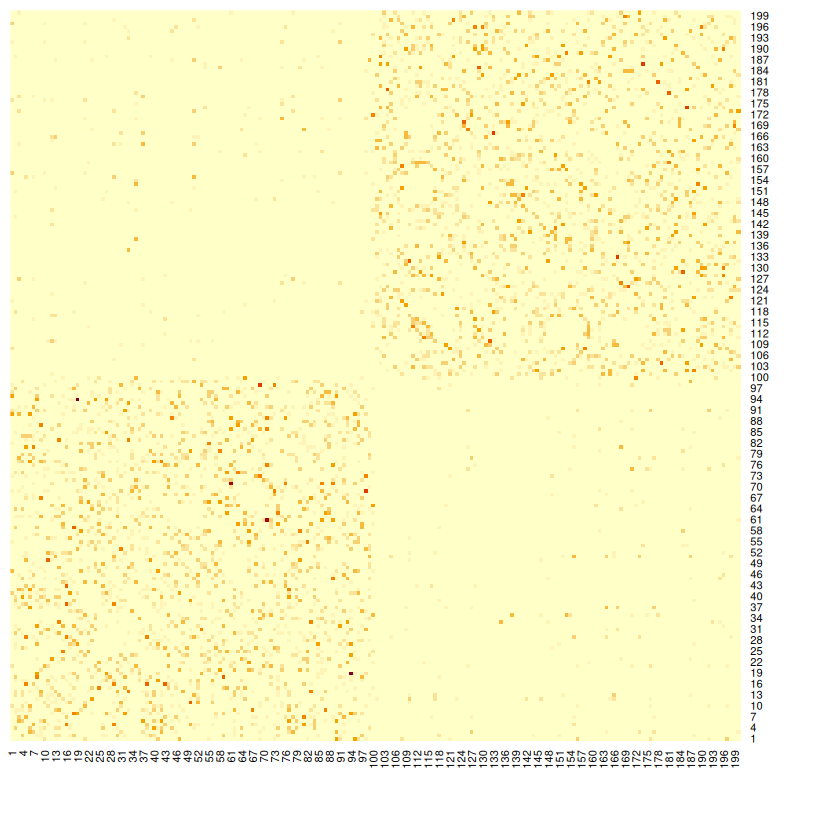

In [14]:
displayClustersWithHeatmap(W, group)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




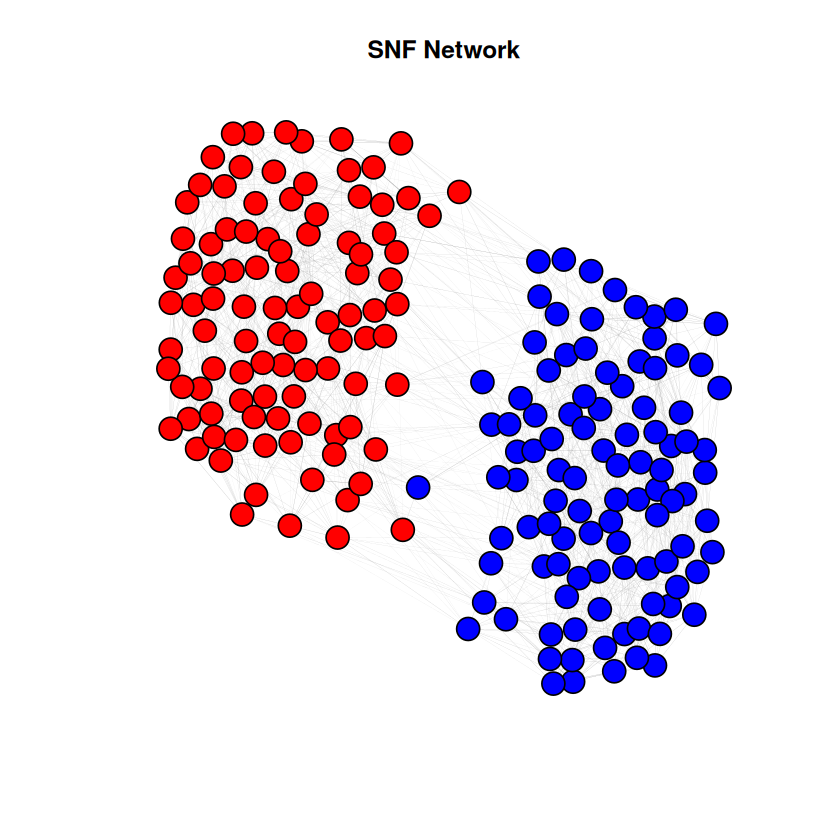

In [15]:
library(igraph)

threshold <- quantile(W[upper.tri(W)], 0.75)
W_thresh <- W
W_thresh[W_thresh < threshold] <- 0

g <- graph_from_adjacency_matrix(W_thresh, mode = "undirected", weighted = TRUE, diag = FALSE)

V(g)$color <- c("red", "blue", "green")[group]
E(g)$width <- E(g)$weight * 5

plot(g, vertex.size = 8, vertex.label = NA, layout = layout_with_fr(g), main = "SNF Network")

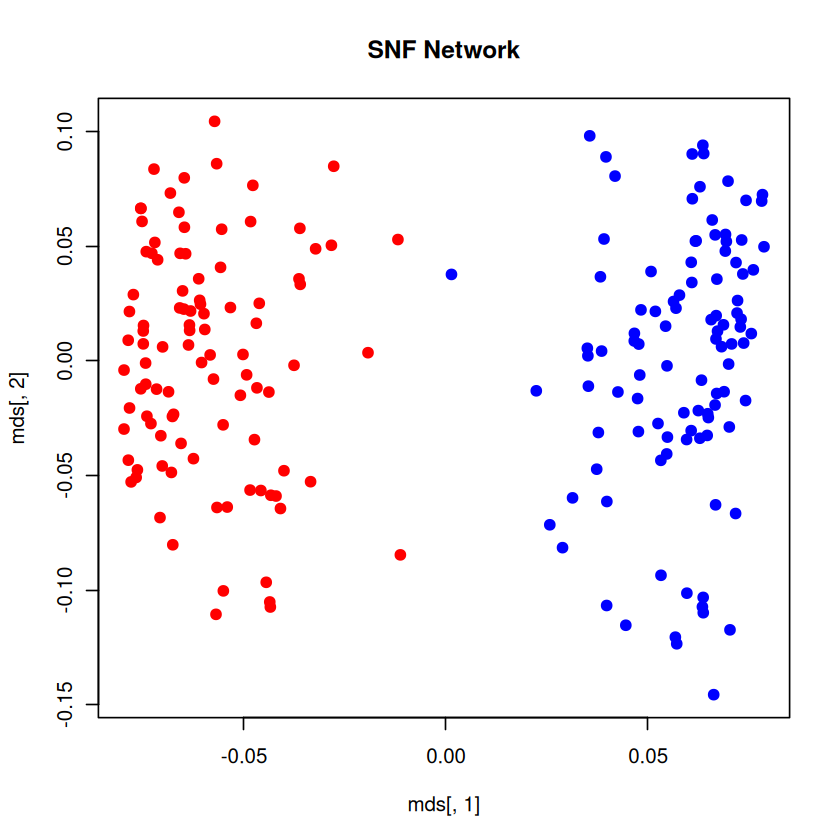

In [16]:
mds <- cmdscale(1 - W, k = 2)
plot(mds[,1], mds[,2], col = c("red", "blue")[group], pch = 19, main = "SNF Network")

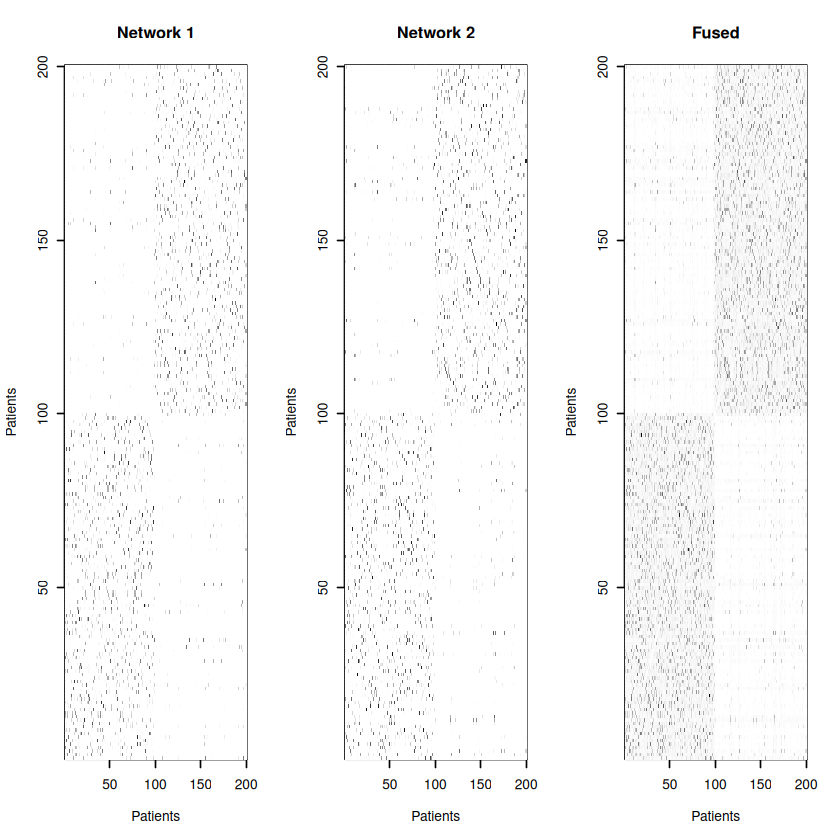

In [17]:
par(mfrow = c(1, 3))
displayClusters(W1, group); title("Network 1")
displayClusters(W2, group); title("Network 2")
displayClusters(W, group); title("Fused")
par(mfrow = c(1, 1))

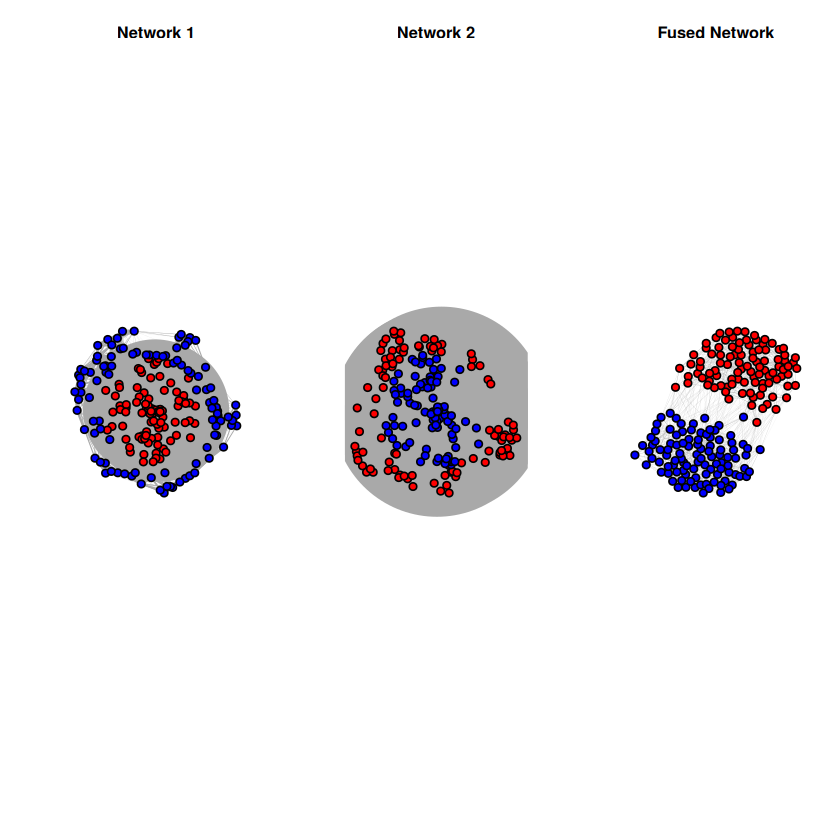

In [18]:
library(igraph)

# Set up 3 plots side by side
par(mfrow = c(1, 3))

# Network 1 Graph

threshold1 <- quantile(W1[upper.tri(W1)], 0.75)
W1_thresh <- W1
W1_thresh[W1_thresh < threshold1] <- 0
g1 <- graph_from_adjacency_matrix(W1_thresh, mode = "undirected", weighted = TRUE, diag = FALSE)
V(g1)$color <- c("red", "blue", "green")[group]
E(g1)$width <- E(g1)$weight * 5
plot(g1, vertex.size = 8, vertex.label = NA, layout = layout_with_fr(g1), main = "Network 1")

# Network 2 Graph

threshold2 <- quantile(W2[upper.tri(W2)], 0.75)
W2_thresh <- W2
W2_thresh[W2_thresh < threshold2] <- 0
g2 <- graph_from_adjacency_matrix(W2_thresh, mode = "undirected", weighted = TRUE, diag = FALSE)
V(g2)$color <- c("red", "blue", "green")[group]
E(g2)$width <- E(g2)$weight * 5
plot(g2, vertex.size = 8, vertex.label = NA, layout = layout_with_fr(g2), main = "Network 2")

# Fused Network Graph

threshold <- quantile(W[upper.tri(W)], 0.75)
W_thresh <- W
W_thresh[W_thresh < threshold] <- 0
g <- graph_from_adjacency_matrix(W_thresh, mode = "undirected", weighted = TRUE, diag = FALSE)
V(g)$color <- c("red", "blue", "green")[group]
E(g)$width <- E(g)$weight * 5
plot(g, vertex.size = 8, vertex.label = NA, layout = layout_with_fr(g), main = "Fused Network")

# Reset to single plot
par(mfrow = c(1, 1))

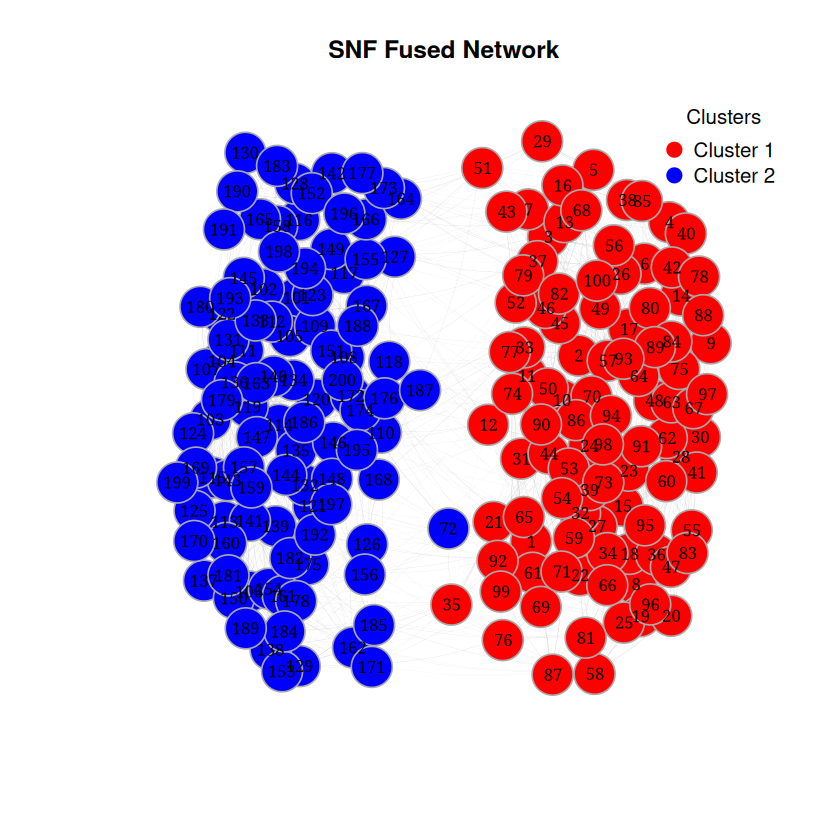

In [19]:
library(igraph)

# Create fused network graph
threshold <- quantile(W[upper.tri(W)], 0.75)
W_thresh <- W
W_thresh[W_thresh < threshold] <- 0

g <- graph_from_adjacency_matrix(W_thresh, mode = "undirected", weighted = TRUE, diag = FALSE)

# Node customization
V(g)$color <- c("red", "blue", "green", "orange", "purple")[group]
V(g)$label <- 1:vcount(g)           # Node IDs
V(g)$label.color <- "black"
V(g)$label.cex <- 0.8
V(g)$size <- 15
V(g)$frame.color <- "darkgray"      # Node border color

# Edge customization
E(g)$width <- E(g)$weight * 5       # Thicker = stronger connection
E(g)$color <- rgb(0.5, 0.5, 0.5, alpha = 0.5)  # Semi-transparent gray
E(g)$curved <- 0.1                  # Slight curve to edges

# Plot
plot(g, 
     layout = layout_with_fr(g),
     main = "SNF Fused Network")

# Add legend
legend("topright", 
       legend = paste("Cluster", sort(unique(group))),
       col = c("red", "blue", "green", "orange", "purple")[sort(unique(group))],
       pch = 19,
       pt.cex = 1.5,
       title = "Clusters",
       bty = "n")

In [20]:
# Nodes (circles)

# Each node = one sample/patient/data point
# Red nodes = Cluster 1 (samples 1-100)
# Blue nodes = Cluster 2 (samples 101-200)
# Numbers inside = sample IDs

# Edges (lines connecting nodes)

# Lines connect samples that are similar to each other
# Only showing connections above a threshold (strongest similarities)
# Thicker edges = stronger similarity between samples

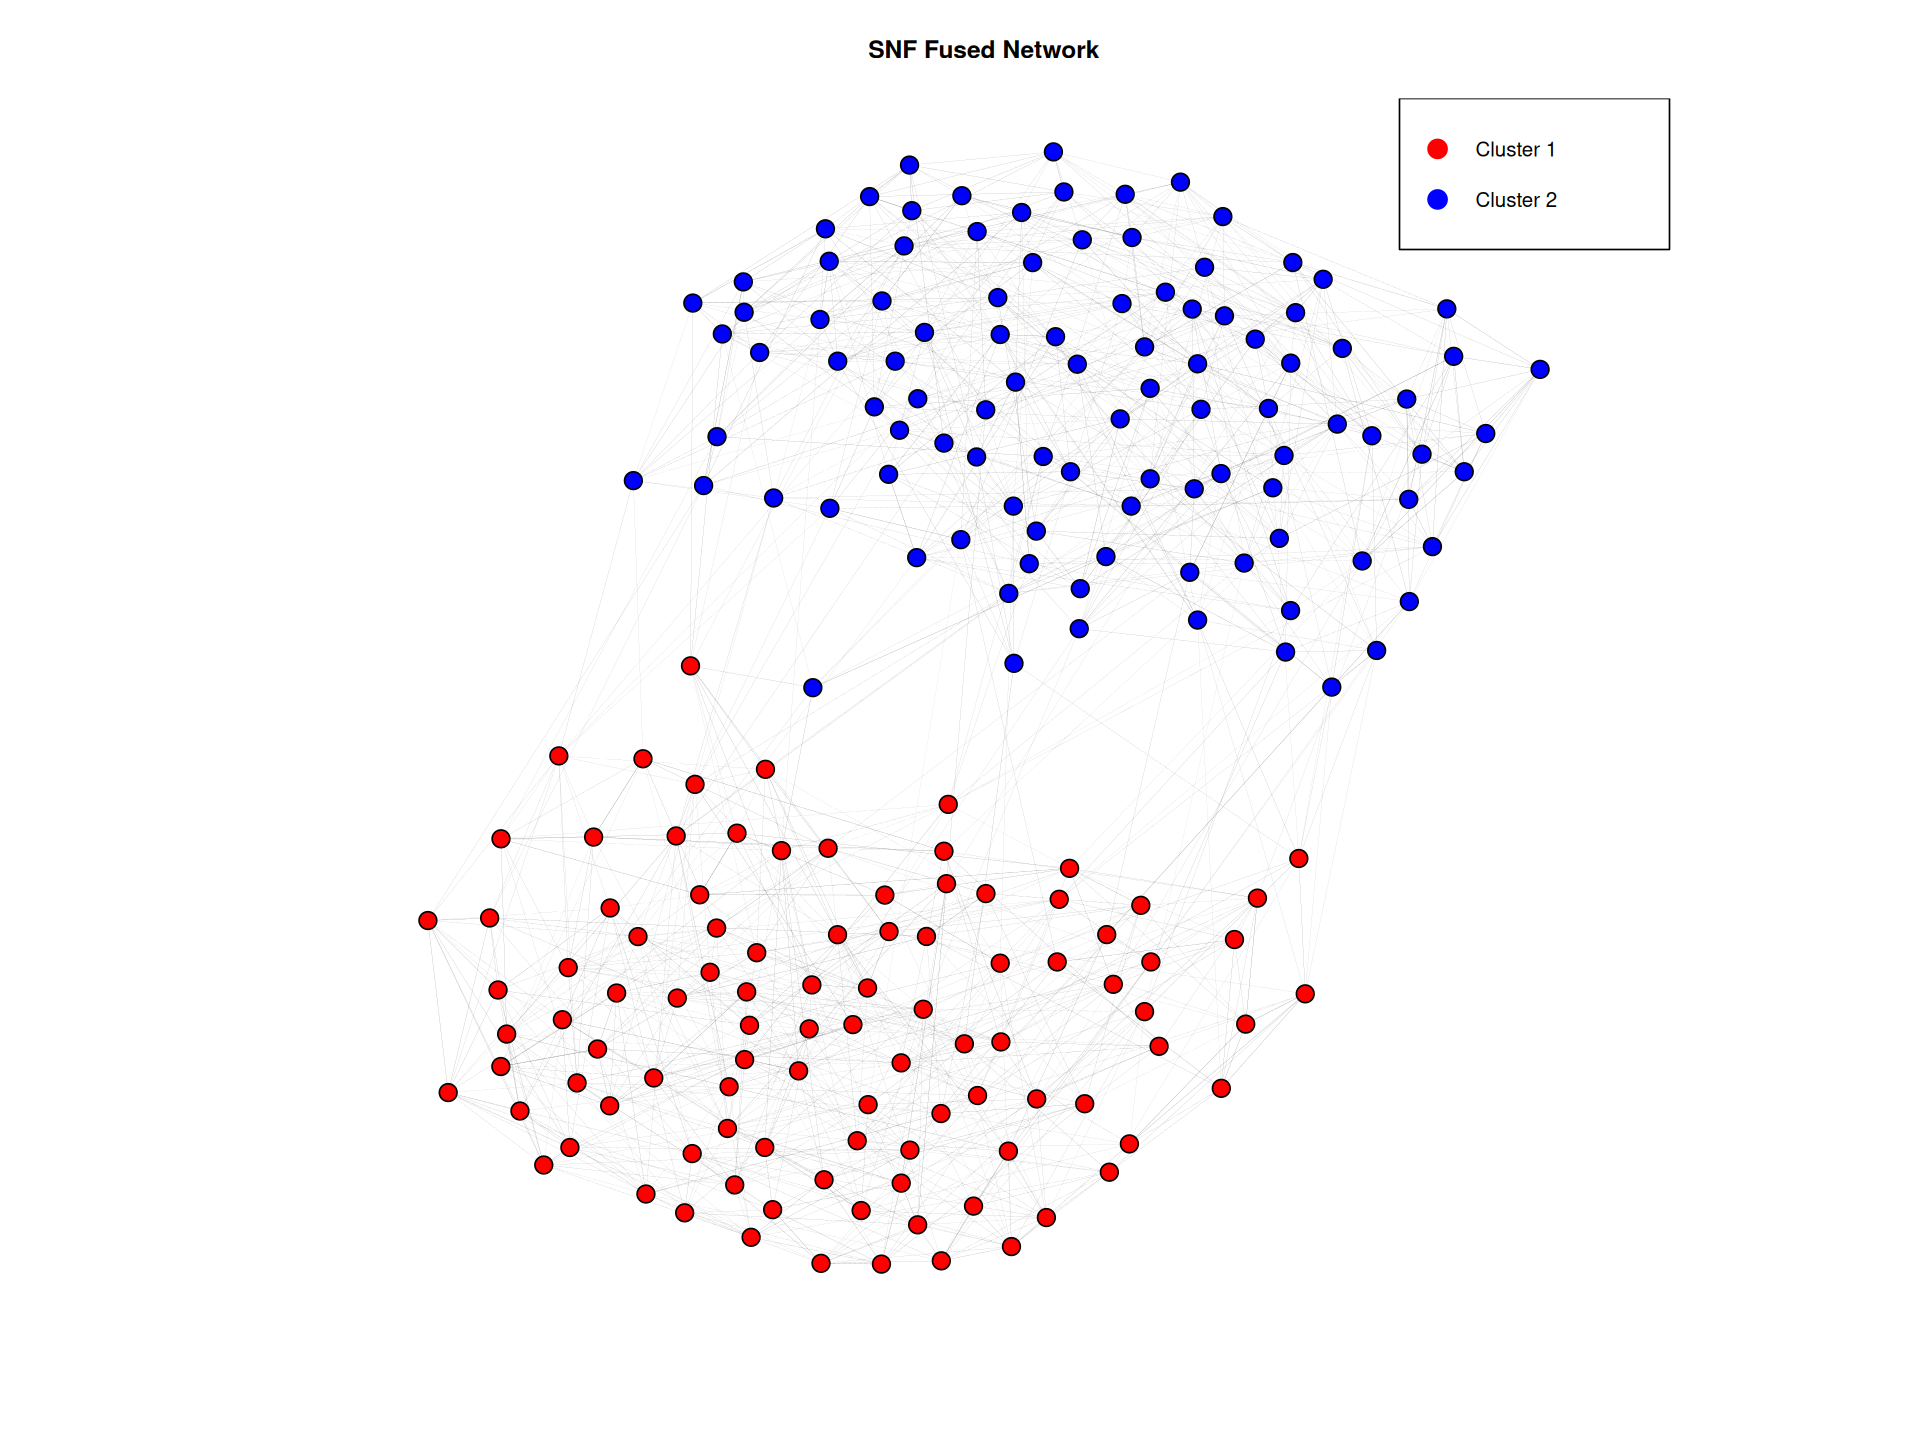

In [21]:
library(igraph)

options(repr.plot.width=16, repr.plot.height=12)

threshold <- quantile(W[upper.tri(W)], 0.75)
W_thresh <- W
W_thresh[W_thresh < threshold] <- 0

g <- graph_from_adjacency_matrix(W_thresh, 
                                 mode = "undirected", 
                                 weighted = TRUE, 
                                 diag = FALSE)

V(g)$color <- c("red", "blue", "green")[group]
V(g)$label <- NA  # Remove labels to see edges better

E(g)$width <- E(g)$weight * 3
E(g)$color <- "gray30"  # Darker edges to see better

plot(g, 
     vertex.size = 3,              # SMALL nodes
     layout = layout_with_fr(g),
     main = "SNF Fused Network")

legend("topright", 
       legend = paste("Cluster", unique(group)),
       col = c("red", "blue"),
       pch = 19,
       pt.cex = 2)

In [22]:
cat("Simply another version of the code")

Simply another version of the code

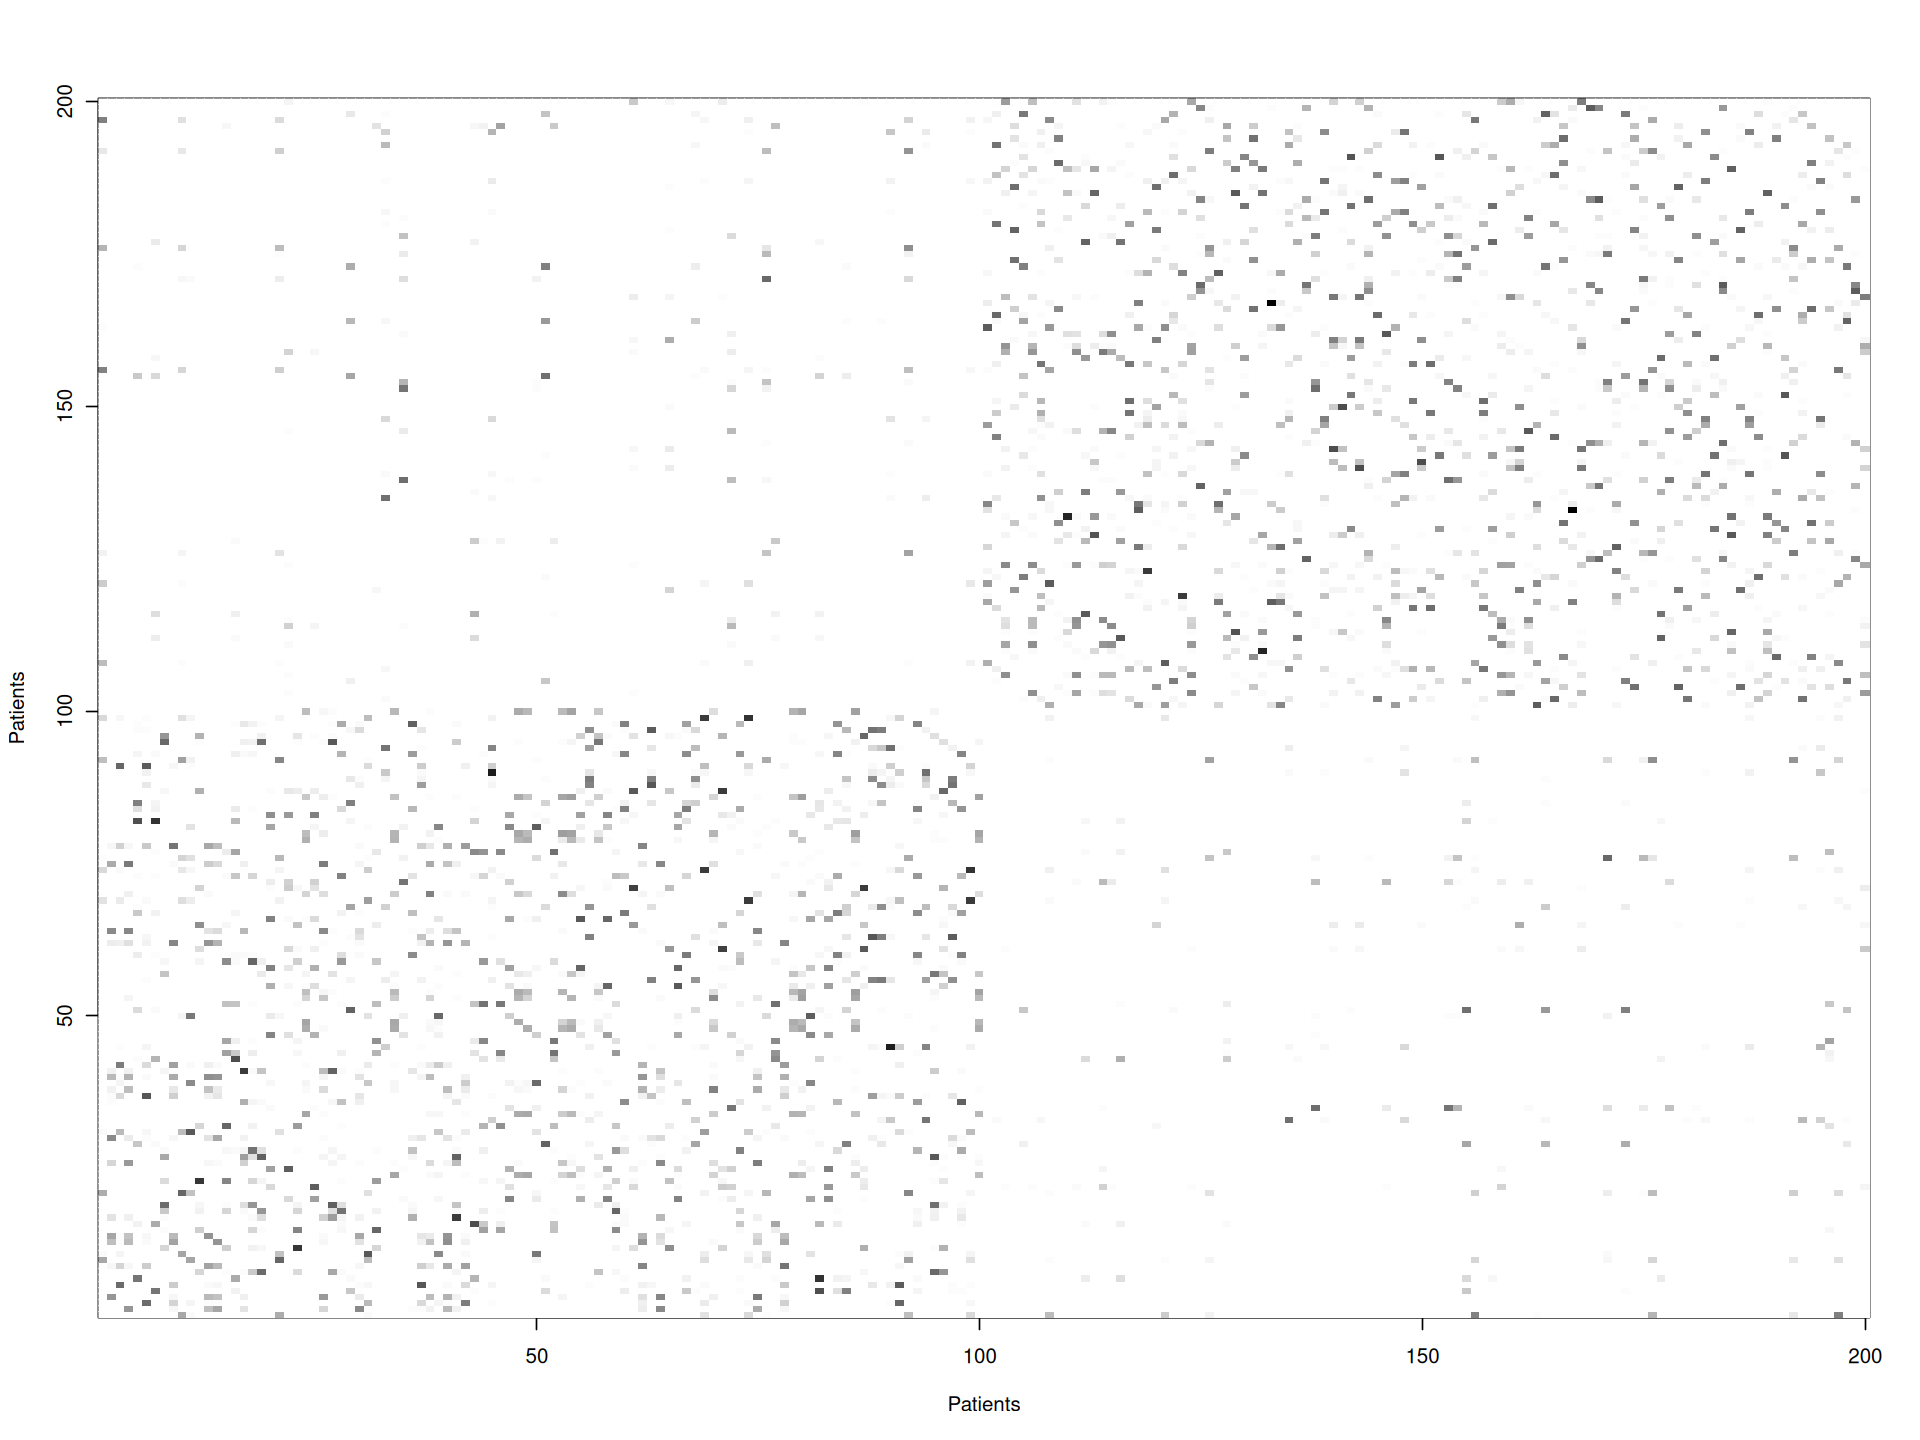

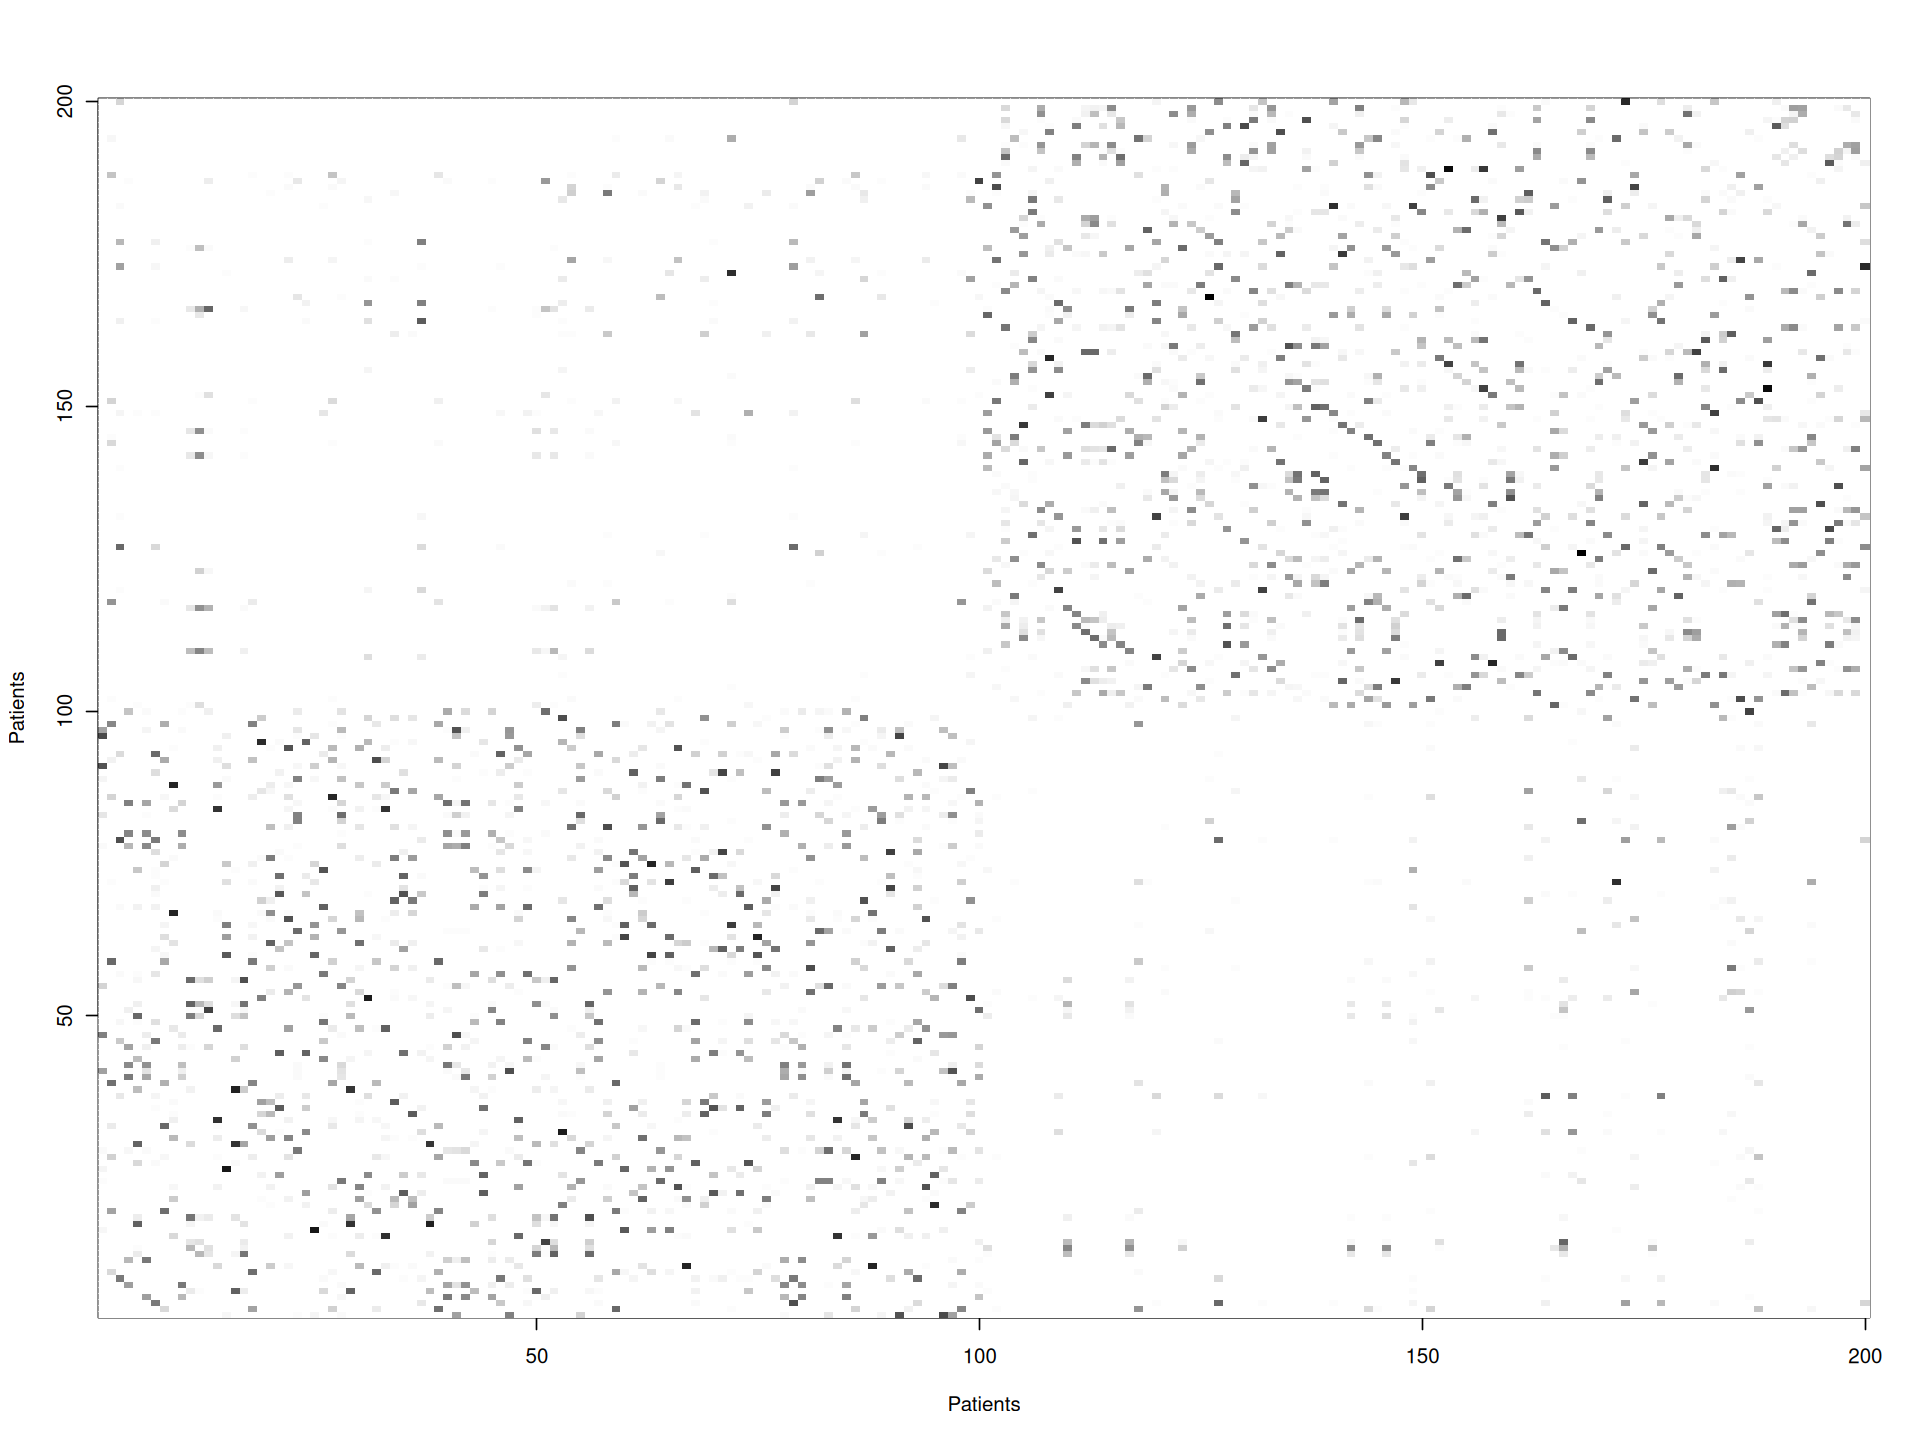

SNF NMI: 0.9595659 
          [,1]      [,2]      [,3]
[1,] 1.0000000 0.4371471 0.1277467
[2,] 0.4371471 1.0000000 0.0605535
[3,] 0.1277467 0.0605535 1.0000000


Warning message in data(Digits):
“data set ‘Digits’ not found”


           [,1]       [,2]
[1,] 1.00000000 0.08011146
[2,] 0.08011146 1.00000000
Digits NMI: 0.6293086 
Label propagation accuracy: 1 


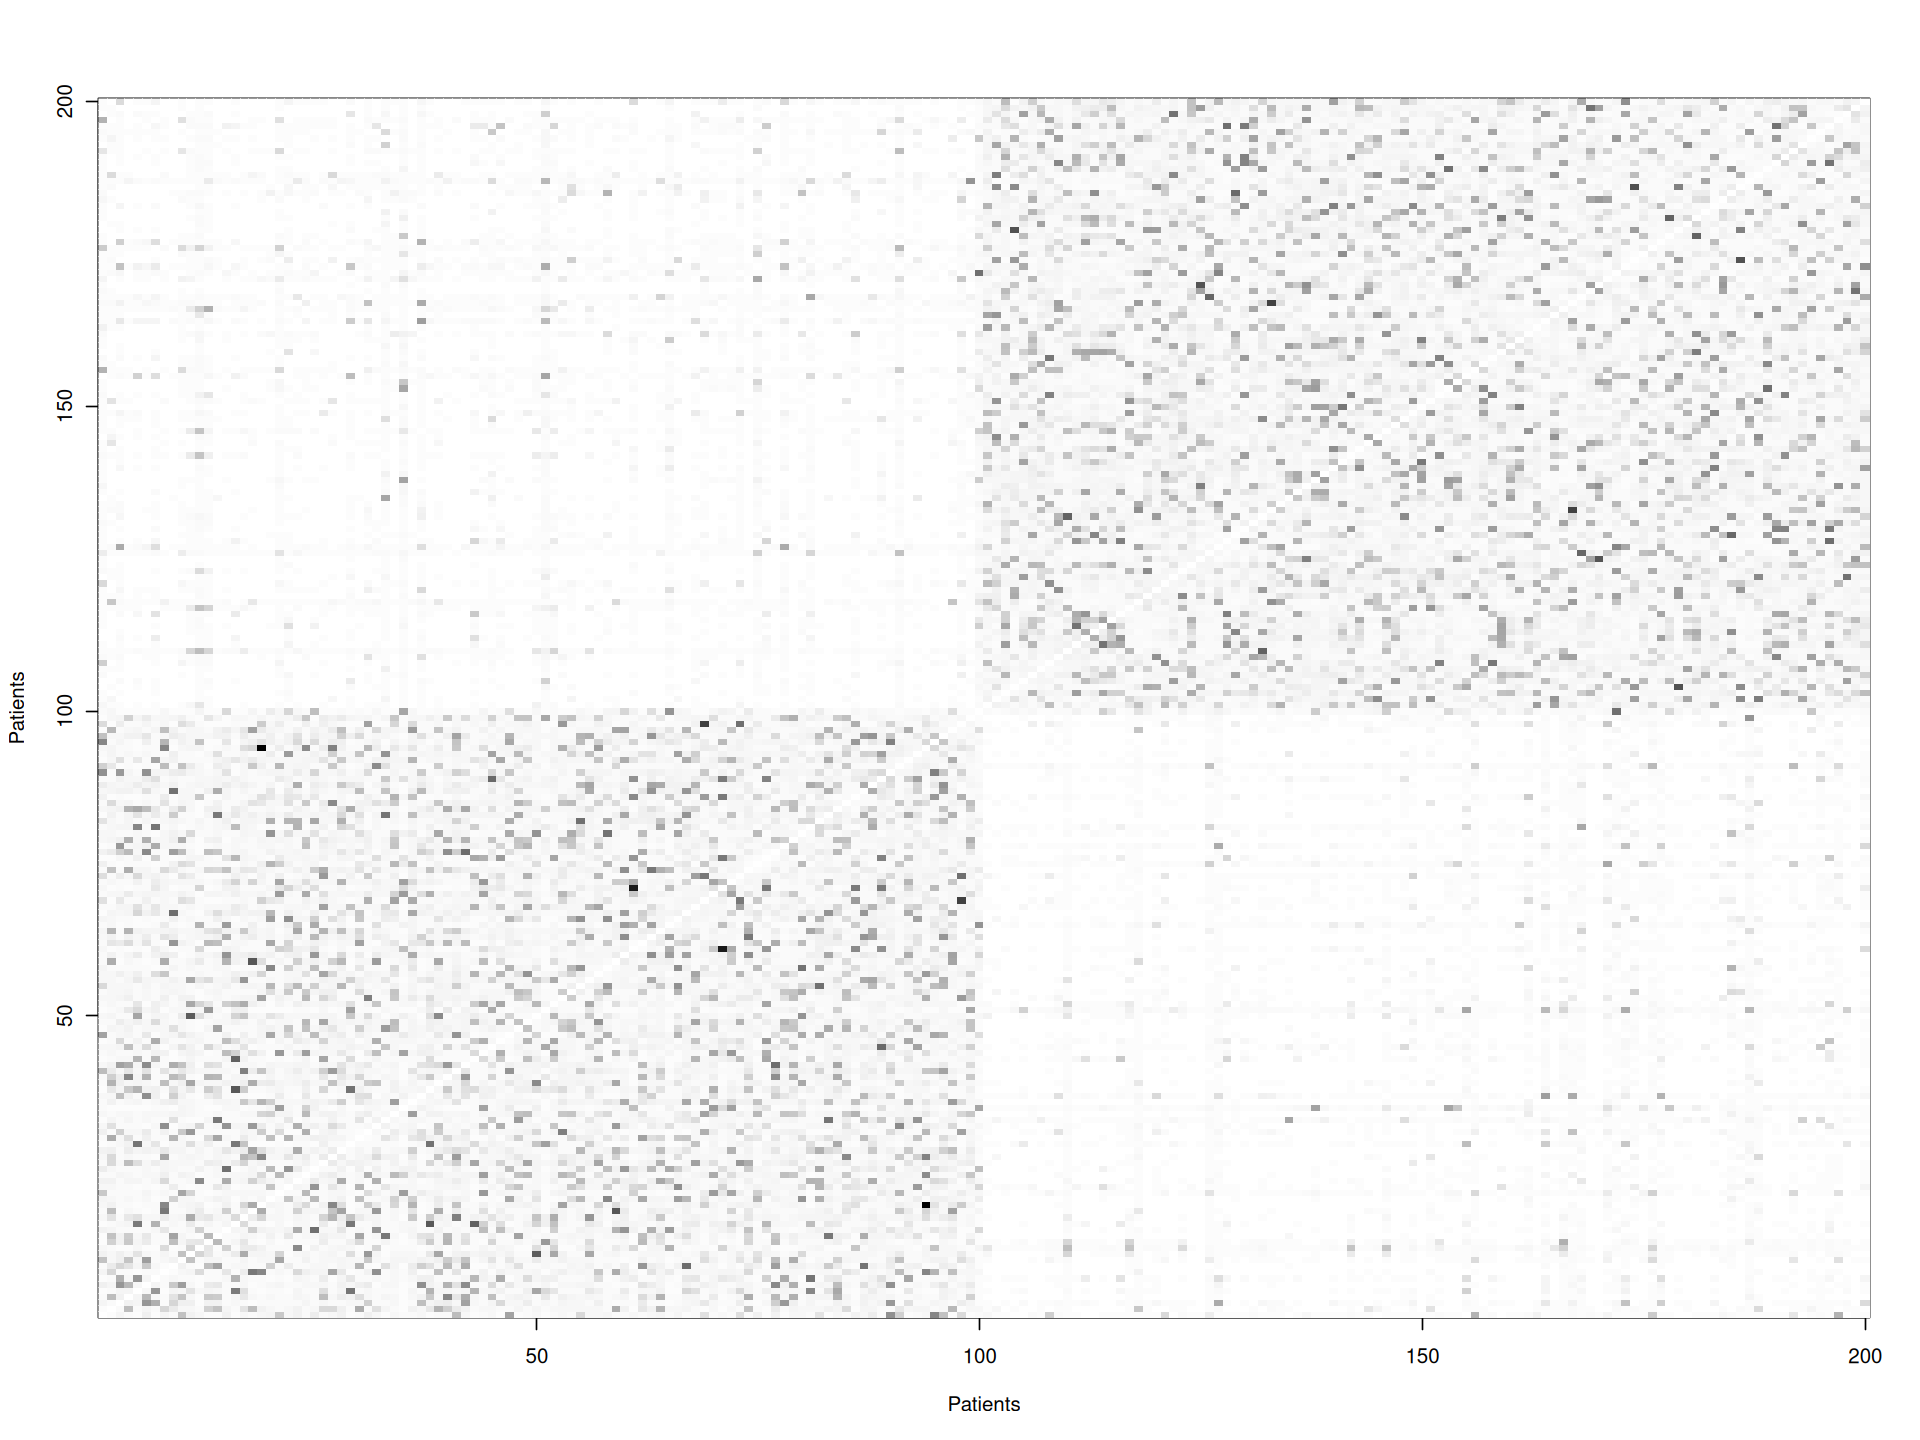

In [23]:
############################################################
# Compatible with CRAN SNFtool
############################################################

library(SNFtool)
set.seed(1)

############################################################
# Basic SNF example (Data1, Data2)
############################################################

# Parameters
K     <- 20    # number of neighbors
T     <- 10    # number of SNF iterations

# Load example data
data(Data1)
data(Data2)

stopifnot(nrow(Data1) == nrow(Data2))
n <- nrow(Data1)

# Ground-truth labels (simulation)
truelabel <- c(rep(1, n/2), rep(2, n/2))

# Normalize (recommended for continuous data)
Data1 <- standardNormalization(Data1)
Data2 <- standardNormalization(Data2)

# Distance matrices (SQUARED Euclidean)
Dist1 <- dist2(as.matrix(Data1), as.matrix(Data1))
Dist2 <- dist2(as.matrix(Data2), as.matrix(Data2))

# Affinity matrices (CRAN-safe: no alpha argument)
W1 <- affinityMatrix(Dist1, K)
W2 <- affinityMatrix(Dist2, K)

# Inspect individual networks
displayClusters(W1, truelabel)
displayClusters(W2, truelabel)

# Similarity Network Fusion
W <- SNF(list(W1, W2), K, T)

# Spectral clustering on fused network
C <- 2
group <- spectralClustering(W, C)

# Inspect fused clustering
displayClusters(W, group)

# Evaluate clustering
SNFNMI <- calNMI(group, truelabel)
cat("SNF NMI:", SNFNMI, "\n")

# Concordance between networks
ConcordanceMatrix <- concordanceNetworkNMI(list(W, W1, W2), C)
print(ConcordanceMatrix)

############################################################
# Multi-view example (Digits)
############################################################

# Load Digits example (provides dataL and label)
data(Digits)

# Parameters
K <- 20
T <- 20

# Normalize each view (optional but recommended)
dataL <- lapply(dataL, standardNormalization)

# Distance matrices
distL <- lapply(dataL, function(x) dist2(x, x))

# Affinity matrices (CRAN-safe)
affinityL <- lapply(distL, function(d) affinityMatrix(d, K))

# Concordance across views
Concordance_matrix <- concordanceNetworkNMI(affinityL, 3)
print(Concordance_matrix)

############################################################
# Subtyping using SNF
############################################################

W_digits <- SNF(affinityL, K, T)
clustering <- spectralClustering(W_digits, 3)

NMI_digits <- calNMI(clustering, label)
cat("Digits NMI:", NMI_digits, "\n")

############################################################
# Label propagation (groupPredict)
############################################################

# Train / test split
n_train <- floor(0.8 * length(label))
trainSample <- sample.int(length(label), n_train)

train  <- lapply(dataL, function(x) x[trainSample, , drop = FALSE])
test   <- lapply(dataL, function(x) x[-trainSample, , drop = FALSE])
groups <- label[trainSample]

# Parameters for prediction
K      <- 20
alpha  <- 0.5
t      <- 20
method <- TRUE

# Predict labels
newLabel <- groupPredict(train, test, groups, K, alpha, t, method)

# Accuracy
pred_test <- tail(newLabel, length(label) - n_train)
accuracy <- mean(label[-trainSample] == pred_test)
cat("Label propagation accuracy:", accuracy, "\n")

############################################################
# End
############################################################


In [24]:
cat("

NMI = Normalized Mutual Information

It's a metric that measures how well your clustering matches the true labels (ground truth).

What NMI tells you:

NMI = 1.0 → Perfect match! Your clusters exactly match the true labels
NMI = 0.0 → No relationship between clusters and true labels (random)
NMI = 0.5-0.8 → Good clustering, captures most of the structure
NMI > 0.8 → Excellent clustering

If you get:

NMI = 0.95  → Your SNF fusion worked great! Almost perfect clustering
NMI = 0.75  → Good! Captured most of the cluster structure
NMI = 0.40  → Poor clustering, missed a lot of the structure
NMI = 0.10  → Failed, clusters don't match reality

")



NMI = Normalized Mutual Information

It's a metric that measures how well your clustering matches the true labels (ground truth).

What NMI tells you:

NMI = 1.0 → Perfect match! Your clusters exactly match the true labels
NMI = 0.0 → No relationship between clusters and true labels (random)
NMI = 0.5-0.8 → Good clustering, captures most of the structure
NMI > 0.8 → Excellent clustering

If you get:

NMI = 0.95  → Your SNF fusion worked great! Almost perfect clustering
NMI = 0.75  → Good! Captured most of the cluster structure
NMI = 0.40  → Poor clustering, missed a lot of the structure
NMI = 0.10  → Failed, clusters don't match reality



In [25]:
cat("

ARI = Adjusted Rand Index
It's another metric that measures how well your clustering matches the true labels, similar to NMI but with different properties.
What ARI tells you:

ARI = 1.0 → Perfect match! Clusters exactly match true labels
ARI = 0.0 → Random clustering (no better than chance)
ARI < 0 → Worse than random (yes, it can be negative!)
ARI = 0.5-0.8 → Good clustering
ARI > 0.8 → Excellent clustering

")



ARI = Adjusted Rand Index
It's another metric that measures how well your clustering matches the true labels, similar to NMI but with different properties.
What ARI tells you:

ARI = 1.0 → Perfect match! Clusters exactly match true labels
ARI = 0.0 → Random clustering (no better than chance)
ARI < 0 → Worse than random (yes, it can be negative!)
ARI = 0.5-0.8 → Good clustering
ARI > 0.8 → Excellent clustering



In [26]:
# Install if needed
# install.packages("mclust")

library(mclust)

# Calculate ARI
ari_score <- adjustedRandIndex(group, truelabel)
cat("ARI =", ari_score, "\n")

Package 'mclust' version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



ARI = 0.9799995 


In [27]:
cat("

| Property                       | **NMI (Normalized Mutual Information)** | **ARI (Adjusted Rand Index)**     |
| ------------------------------ | --------------------------------------- | --------------------------------- |
| Value range                    | **0 to 1**                              | **−1 to 1**                       |
| Interpretation                 | Information-theoretic similarity        | Agreement-based similarity        |
| Handles unequal cluster sizes  | **Yes**                                 | **Yes**                           |
| Baseline for random clustering | **0**                                   | **0**                             |
| Can be negative?               | **No**                                  | **Yes**                           |
| Popular in                     | Machine learning, clustering            | Statistics, clustering validation |

")



| Property                       | **NMI (Normalized Mutual Information)** | **ARI (Adjusted Rand Index)**     |
| ------------------------------ | --------------------------------------- | --------------------------------- |
| Value range                    | **0 to 1**                              | **−1 to 1**                       |
| Interpretation                 | Information-theoretic similarity        | Agreement-based similarity        |
| Handles unequal cluster sizes  | **Yes**                                 | **Yes**                           |
| Baseline for random clustering | **0**                                   | **0**                             |
| Can be negative?               | **No**                                  | **Yes**                           |
| Popular in                     | Machine learning, clustering            | Statistics, clustering validation |

